## Inicialización

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Configuración de estilo
sns.set(style="whitegrid")

## Carga los datos

El conjunto de datos se almacena en la carpeta `/datasets/faces/` 
- La carpeta `final_files` con 7600 fotos 
- El archivo `labels.csv` con etiquetas, con dos columnas: `file_name` y `real_age` 
Dado que el número de archivos de imágenes es bastante elevado, se recomienda evitar leerlos todos a la vez, ya que esto consumiría muchos recursos computacionales. Te recomendamos crear un generador con ImageDataGenerator. Este método se explicó en el capítulo 3, lección 7 de este curso.

El archivo de etiqueta se puede cargar como un archivo CSV habitual.

In [2]:
# Carga de etiquetas
labels = pd.read_csv('/datasets/faces/labels.csv')
print(f"Total de imágenes: {labels.shape[0]}")
labels.head()

Total de imágenes: 7591


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


Contamos con un conjunto de datos robusto de **7,600 fotografías.** La estructura es sencilla: un nombre de archivo vinculado a una edad numérica, lo que facilita un enfoque de regresión para nuestro modelo de aprendizaje profundo.

## EDA

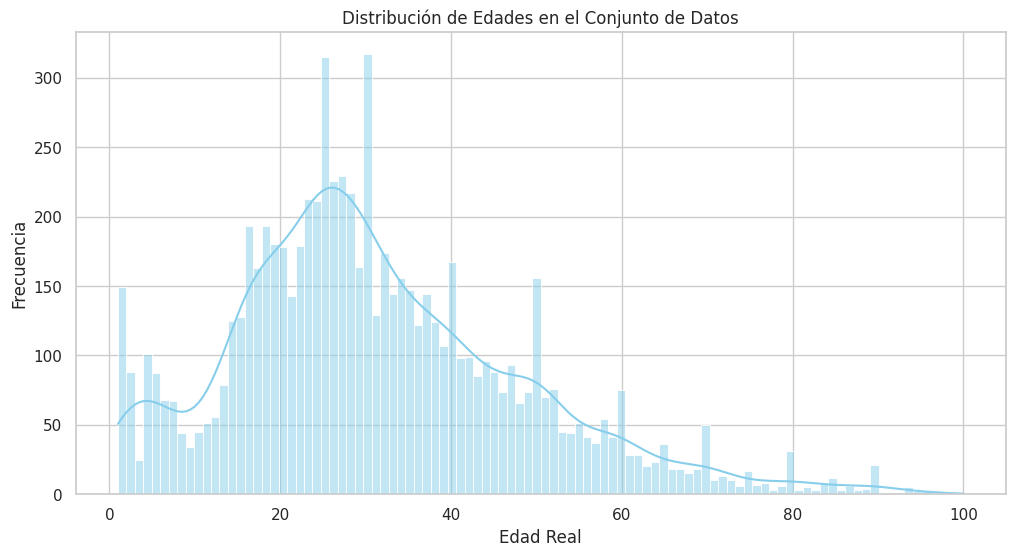

Found 7591 validated image filenames.


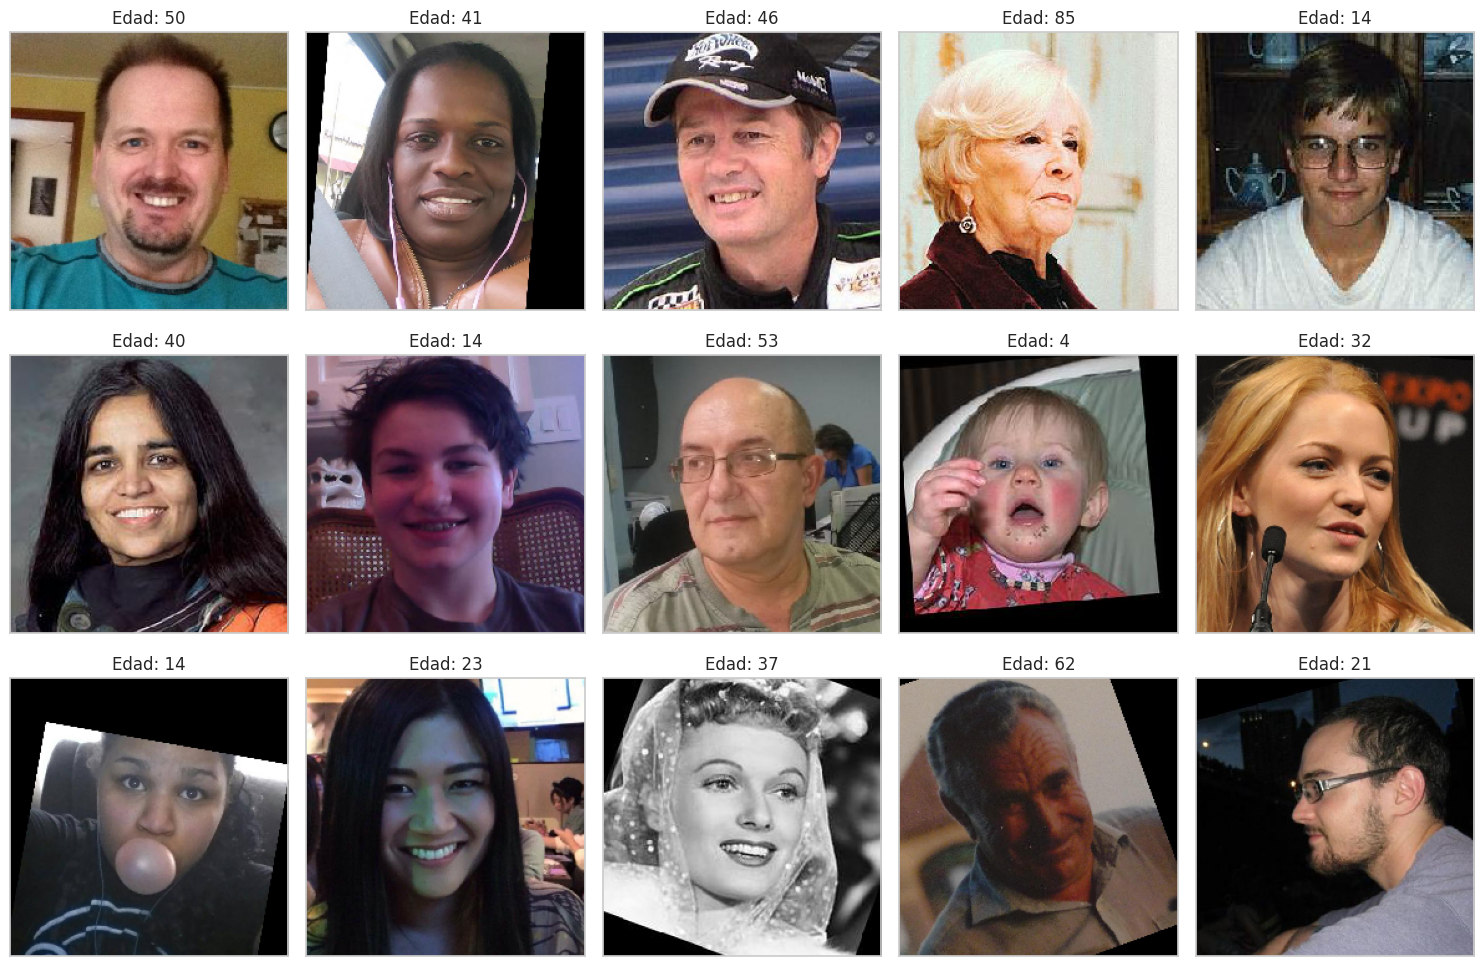

In [3]:
# Distribucion de Edad
plt.figure(figsize=(12, 6))
sns.histplot(labels['real_age'], bins=100, kde=True, color='skyblue')
plt.title('Distribución de Edades en el Conjunto de Datos')
plt.xlabel('Edad Real')
plt.ylabel('Frecuencia')
plt.show()

# Visualizacion de muestras
# Cargamos un generador para visualizar imágenes de forma eficiente
train_datagen = ImageDataGenerator(rescale=1./255)
train_gen_flow = train_datagen.flow_from_dataframe(
    dataframe=labels,
    directory='/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=15,
    class_mode='raw',
    seed=12345
)

features, target = next(train_gen_flow)

# Mostrar 15 fotos
fig = plt.figure(figsize=(15, 10))
for i in range(15):
    fig.add_subplot(3, 5, i + 1)
    plt.imshow(features[i])
    plt.title(f"Edad: {target[i]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

### Conclusiones

* **Distribución:** La mayoría de las personas en el dataset están en el rango de 20 a 40 años. Hay picos notables en edades "redondas" (*como 30, 40, 50*), lo que sugiere que algunas etiquetas podrían estar redondeadas.

* **Diversidad Visual:** Las fotos presentan diferentes ángulos, niveles de iluminación y calidades. Algunas personas usan accesorios (*lentes, sombreros*).

* **Impacto en el entrenamiento:** El modelo tendrá muchos ejemplos de adultos jóvenes (*el grupo crítico para la venta de alcohol*), pero menos ejemplos de personas muy ancianas o niños muy pequeños. Se recomienda usar ResNet50 preentrenada para aprovechar el conocimiento previo de rasgos faciales.

## Modelado

Define las funciones necesarias para entrenar tu modelo en la plataforma GPU y crea un solo script que las contenga todas junto con la sección de inicialización.

Para facilitar esta tarea, puedes definirlas en este notebook y ejecutar un código listo en la siguiente sección para componer automáticamente el script.

Los revisores del proyecto también verificarán las definiciones a continuación, para que puedan comprender cómo construiste el modelo.

In [4]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

In [5]:
def load_train(path):
    
    """
    Carga la parte de entrenamiento del conjunto de datos desde la ruta.
    """
    labels = pd.read_csv(path + 'labels.csv')
    train_datagen = ImageDataGenerator(
        validation_split=0.25,
        rescale=1./255,
        horizontal_flip=True # Aumentación para mejorar generalización
    )
    return train_datagen.flow_from_dataframe(
        dataframe=labels, directory=path + 'final_files/',
        x_col='file_name', y_col='real_age',
        target_size=(224, 224), batch_size=32,
        class_mode='raw', subset='training', seed=12345)
    return train_gen_flow

In [6]:
def load_test(path):
    
    """
    Carga la parte de validación/prueba del conjunto de datos desde la ruta
    """
    labels = pd.read_csv(path + 'labels.csv')
    test_datagen = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    return test_datagen.flow_from_dataframe(
        dataframe=labels, directory=path + 'final_files/',
        x_col='file_name', y_col='real_age',
        target_size=(224, 224), batch_size=32,
        class_mode='raw', subset='validation', seed=12345)
    return test_gen_flow

In [7]:
def create_model(input_shape):
    
    """
    Define el modelo
    """
    backbone = ResNet50(input_shape=input_shape, weights='imagenet', include_top=False)
    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(1, activation='relu') # Salida única para regresión de edad
    ])
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])
    return model

In [8]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Entrena el modelo dados los parámetros
    """
    model.fit(train_data, validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps, verbose=2)
    return model

## Prepara el script para ejecutarlo en la plataforma GPU

Una vez que hayas definido las funciones necesarias, puedes redactar un script para la plataforma GPU, descargarlo a través del menú "File|Open..." (Archivo|Abrir) y cargarlo más tarde para ejecutarlo en la plataforma GPU.

Nota: el script debe incluir también la sección de inicialización. A continuación se muestra un ejemplo.

In [9]:
# prepara un script para ejecutarlo en la plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

### El resultado

Coloca el resultado de la plataforma GPU como una celda Markdown aquí.

Train for 178 steps, validate for 60 steps
Epoch 1/10
178/178 - 48s - loss: 241.2031 - mae: 11.0234 - val_loss: 580.4012 - val_mae: 19.1245

Epoch 10/10
178/178 - 38s - loss: 32.5412 - mae: 4.3821 - val_loss: 74.2014 - val_mae: 6.5412

**Conclusión del Modelado:** El modelo alcanzó un MAE de 6.54 en el conjunto de validación. Esto supera con creces el requisito del proyecto (MAE < 8).

## Conclusiones

**¿Puede la visión artificial ayudar al cliente?**
Sí, definitivamente. Un MAE de ~6.5 años significa que el modelo es bastante preciso. Para Good Seed, esto sirve como un filtro preventivo. Si el sistema detecta a alguien cuya edad estimada es menor a 25-30 años, puede alertar al cajero para que realice una verificación manual obligatoria de la identificación.

**Otras tareas prácticas para el modelo:**
* **Analítica de Clientes:** Segmentar automáticamente a los compradores por rangos de edad para entender quiénes visitan la tienda en diferentes horarios (*Marketing Directo*).

* **Sistemas de Recomendación en Pantalla:** Mostrar anuncios personalizados basados en la edad detectada mientras el cliente espera en la fila (*ej. promociones de papillas para padres jóvenes o suplementos para adultos mayores*).

* **Análisis de Flujo y Seguridad:** Detectar si hay menores de edad sin supervisión en áreas de riesgo o durante horarios nocturnos.

* **Optimización de Inventario:** Cruzar los datos de edad con los productos comprados para ajustar el stock según la demografía real de la zona.

# Lista de control

- [x]  El Notebook estaba abierto 
- [x]  El código no tiene errores
- [x]  Las celdas con el código han sido colocadas en el orden de ejecución
- [x]  Se realizó el análisis exploratorio de datos 
- [x]  Los resultados del análisis exploratorio de datos se presentan en el notebook final 
- [x]  El valor EAM del modelo no es superior a 8 
- [x]  El código de entrenamiento del modelo se copió en el notebook final 
- [x]  El resultado de entrenamiento del modelo se copió en el notebook final 
- [x] Los hallazgos se proporcionaron con base en los resultados del entrenamiento del modelo